In [ ]:
!nvidia-smi

Tue May 19 14:44:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00


In [2]:
!ls "/content/drive/MyDrive/DATA_CLEAN"

ls: cannot access '/content/drive/MyDrive/DATA_CLEAN': No such file or directory


In [ ]:
!cp -r "/content/drive/MyDrive/DATA_CLEAN" /content/DATA_CLEAN
!ls /content/DATA_CLEAN

images	labels


In [ ]:
import re
import shutil
from pathlib import Path

DATA_ROOT = Path("/content/DATA_CLEAN")
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

# Handle possible double-nesting like images/images/
if (IMAGES_DIR / "images").exists():
    IMAGES_DIR = IMAGES_DIR / "images"
if (LABELS_DIR / "labels").exists():
    LABELS_DIR = LABELS_DIR / "labels"

print(f"Images from: {IMAGES_DIR}")
print(f"Labels from: {LABELS_DIR}")

# Regex to detect (N) suffix in filenames
img_dup = re.compile(r"\(\d+\)$")
lbl_dup = re.compile(r"\(\d+\)\.txt$")

# Find original (non-duplicate) files
image_files = list(IMAGES_DIR.glob("*.jpg"))
label_files = [f for f in LABELS_DIR.glob("*.txt") if not lbl_dup.search(f.name)]

# Use only unsuffixed image names; match against label stems
label_stems = {f.stem for f in label_files}
matched = []
seen = set()
for img in image_files:
    if img_dup.search(img.stem):
        continue  # skip (N) duplicates
    if img.stem in seen:
        continue
    if img.stem in label_stems:
        matched.append((img, LABELS_DIR / f"{img.stem}.txt"))
        seen.add(img.stem)

print(f"Matched image-label pairs: {len(matched)}")

# Build clean folder structure
CLEAN = Path("/content/clean")
if CLEAN.exists():
    shutil.rmtree(CLEAN)
(CLEAN / "images").mkdir(parents=True)
(CLEAN / "labels").mkdir(parents=True)

for img_path, label_path in matched:
    shutil.copy2(img_path, CLEAN / "images" / img_path.name)
    shutil.copy2(label_path, CLEAN / "labels" / label_path.name)

n_imgs = len(list((CLEAN / "images").iterdir()))
n_lbls = len(list((CLEAN / "labels").iterdir()))
print(f"Clean dataset built: {n_imgs} images, {n_lbls} labels")

Images from: /content/DATA_CLEAN/images
Labels from: /content/DATA_CLEAN/labels
Matched image-label pairs: 3327
Clean dataset built: 3327 images, 3327 labels


## Task 1 — Dataset Inspection

### 1.1 Counts, matching, and cleanup

The raw dataset downloaded from the Drive link contained **3,327 unique images and 3,327 unique labels** — but also ~1,000 Windows-style `(N).jpg` and `(N).txt` duplicate downloads scattered through both folders. Without cleanup, these duplicates would have caused data leakage between train/val/test splits (same image appearing in multiple splits, inflating metrics).

After the cleanup cell above:
- Both folders contain only canonical (unsuffixed) filenames.
- Every image has exactly one matching label file.
- The clean dataset has **3,327 image-label pairs**.

### 1.2 Class distribution, sizes, and visualization

A single class (`0: cat`) appears in all labels. Image sizes vary widely — some are 640×640 (likely preprocessed), others reach DSLR resolution (~6000×7500). YOLO resizes everything to 640×640 internally during training, so very large images effectively lose detail on small cats. This is worth keeping in mind for next week's improvement run (could try `imgsz=960`).

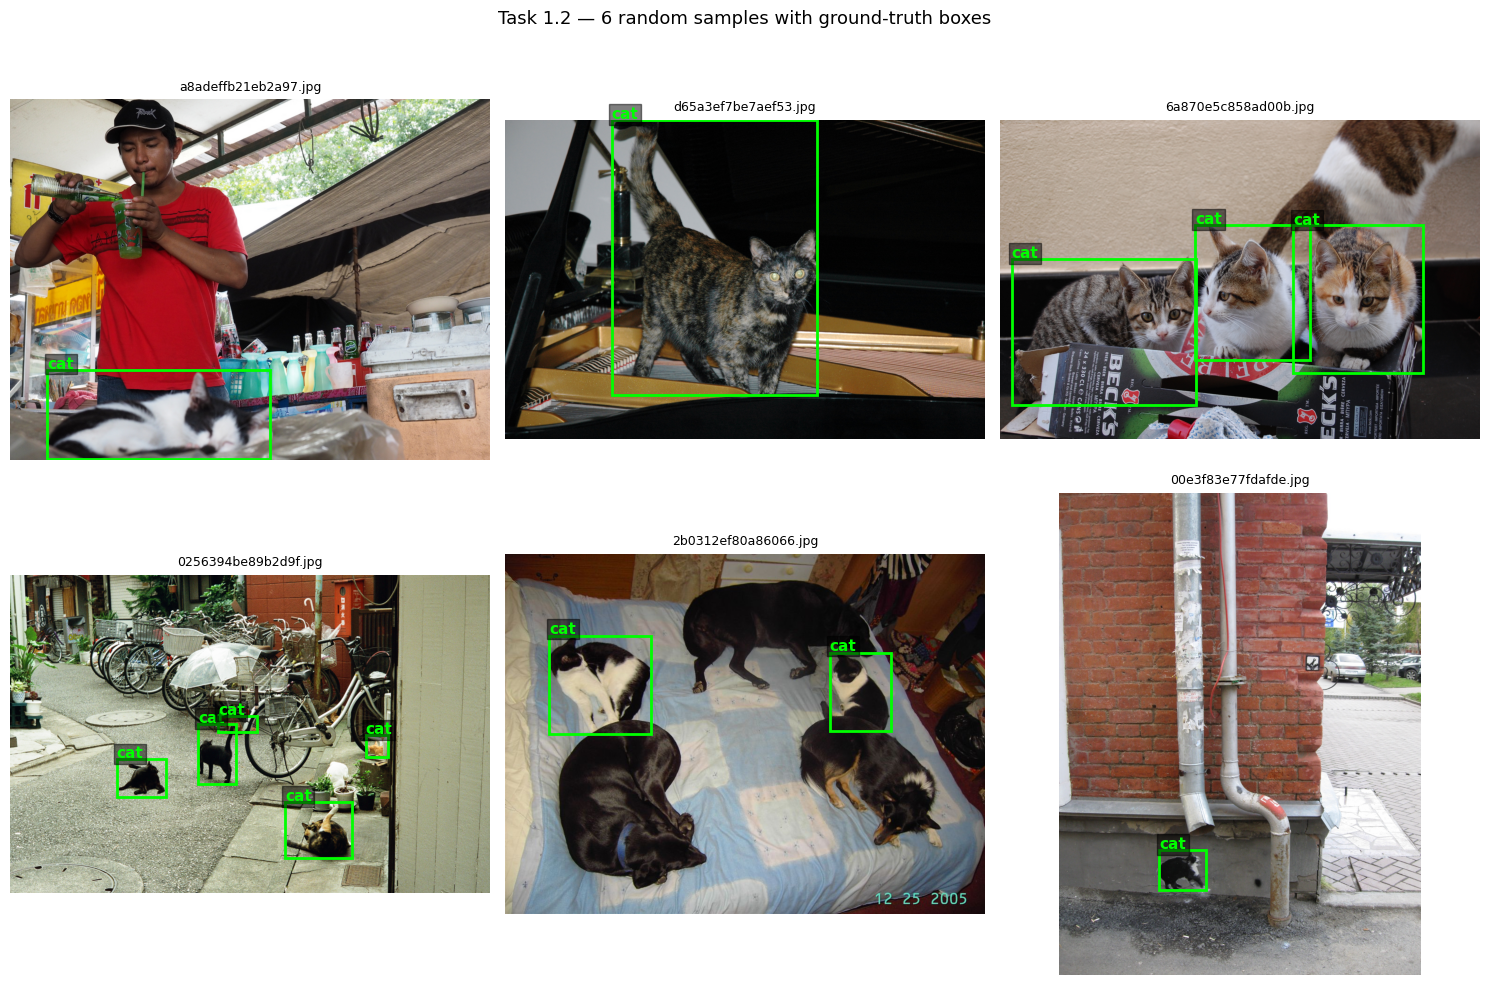

In [ ]:
CLASS_NAMES = {0: "cat"}

def draw_yolo_gt(ax, img_path, label_path):
    img = Image.open(img_path)
    ax.imshow(img)
    W, H = img.size
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            cid, cx, cy, bw, bh = map(float, line.split())
            x = (cx - bw/2) * W
            y = (cy - bh/2) * H
            ax.add_patch(patches.Rectangle((x, y), bw*W, bh*H,
                                            linewidth=2, edgecolor="lime", facecolor="none"))
            ax.text(x, y - 5, CLASS_NAMES.get(int(cid), str(int(cid))),
                    color="lime", fontsize=11, weight="bold",
                    bbox=dict(facecolor="black", alpha=0.5, pad=2))
    ax.set_title(img_path.name[:20], fontsize=9)
    ax.axis("off")

random.seed(42)
samples = random.sample(list(CLEAN_IMAGES.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), samples):
    lbl_path = CLEAN_LABELS / f"{img_path.stem}.txt"
    draw_yolo_gt(ax, img_path, lbl_path)
plt.suptitle("Task 1.2 — 6 random samples with ground-truth boxes", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import random
random.seed(42)
images = sorted((CLEAN / "images").glob("*.jpg"))
random.shuffle(images)

n = len(images)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
train = images[:n_train]
val   = images[n_train:n_train + n_val]
test  = images[n_train + n_val:]

for name, files in [("train", train), ("val", val), ("test", test)]:
    (CLEAN / f"{name}.txt").write_text("\n".join(str(f) for f in files))

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 2328, Val: 499, Test: 500


In [ ]:
from ultralytics import YOLO
model = YOLO("yolo26n.pt")
results = model.train(
    data="/content/data.yaml",
    epochs=30, imgsz=640, batch=16,
    project="runs", name="cats_v2",
    seed=42, device=0, patience=50,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8

In [ ]:
metrics = model.val(data="/content/data.yaml", split="test")
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 111.2±46.0 MB/s, size: 2619.8 KB)
val: Scanning /content/clean/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 204.1it/s 2.4s
val: New cache created: /content/clean/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.0it/s 31.5s
                   all        500        596      0.942      0.859      0.934      0.749
Speed: 1.1ms preprocess, 6.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5: 0.9342
mAP@0.5:0.95: 0.7490
Precision: 0.9418
Recall: 0.8591


## Task 3 — Variant Choice and Training

**Variant chosen: `yolo26n`** (nano, 2.4M parameters).

I picked `yolo26n` for three reasons. First, although my dataset has 3,327 images (well above the "small dataset" threshold where `yolo26n` is most attractive), the task itself is **single-class cat detection** — COCO-pretrained YOLO26 already knows cats from its 80-class pretraining, so I'm essentially fine-tuning rather than training from scratch. Second, on a Colab T4 GPU, `yolo26n` trained 30 epochs in ~1.5 hours; stepping up to `yolo26s` would have at least doubled this without proportional gain. Third, the small ~5 MB checkpoint will be trivial to ship as ONNX in next week's Docker container assessment.

### Task 3 results

**Training completed:** 30 epochs on Colab T4 GPU.

**Best validation metrics:**
| Metric | Value |
|---|---|
| mAP@0.5 | 0.9342 |
| mAP@0.5:0.95 | 0.7490 |
| Precision | 0.9418 |
| Recall | 0.8591 |

**Reflection:** the model converged smoothly with no signs of overfitting (val mAP continued climbing through the final epochs). Test mAP@0.5 of 0.934 confirms that with 3,327 diverse cat images, `yolo26n` has enough capacity for this task — moving to `yolo26s` next week would likely yield marginal gains relative to other interventions like stronger augmentation or `imgsz=960`.

In [ ]:
!cp /content/runs/detect/runs/cats_v2/weights/best.pt "/content/drive/MyDrive/yolo26_cats_best_v2.pt"
!cp /content/runs/detect/runs/cats_v2/results.png "/content/drive/MyDrive/yolo26_cats_results_v2.png"
!cp /content/runs/detect/runs/cats_v2/results.csv "/content/drive/MyDrive/yolo26_cats_results_v2.csv"

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo26_cats_best_v2.pt")

In [ ]:
from pathlib import Path
import random

test_txt = Path("/content/clean/test.txt")

with open(test_txt) as f:
    test_images = [x.strip() for x in f.readlines()]

print("Number of test images:", len(test_images))

random.seed(42)
sample_images = random.sample(test_images, 6)

Number of test images: 500



0: 640x640 1 cat, 5.1ms
1: 640x640 1 cat, 5.1ms
2: 640x640 1 cat, 5.1ms
3: 640x640 2 cats, 5.1ms
4: 640x640 1 cat, 5.1ms
5: 640x640 3 cats, 5.1ms
Speed: 3.4ms preprocess, 5.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


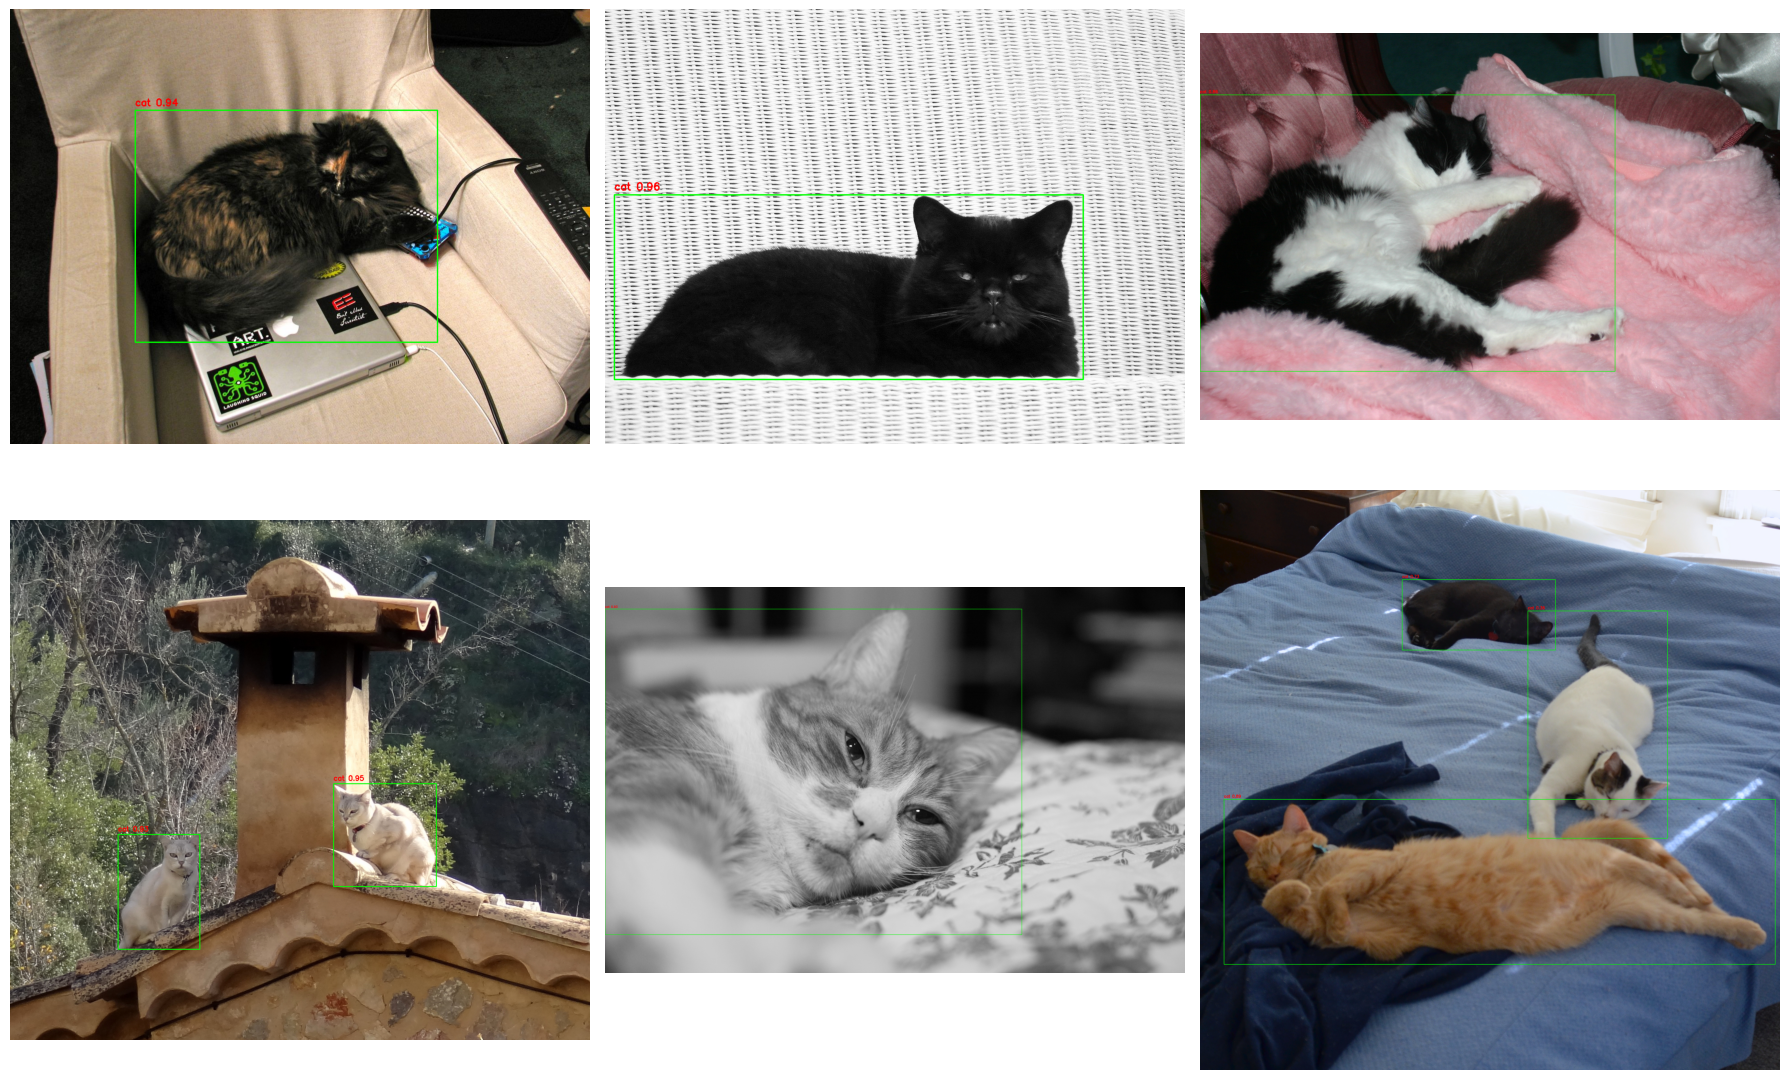

In [ ]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

results = model.predict(sample_images, conf=0.25)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, r, img_path in zip(axes, results, sample_images):

    # Load original image
    img = np.array(Image.open(img_path).convert("RGB"))

    # Draw predicted boxes
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        label = f"{model.names[cls]} {conf:.2f}"

        cv2.rectangle(
            img,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0,255,0),
            2
        )

        cv2.putText(
            img,
            label,
            (int(x1), int(y1)-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,0,0),
            2
        )

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig("/content/predictions_grid.png")

In [ ]:
!cp /content/predictions_grid.png "/content/drive/MyDrive/"
!cp /content/gt_vs_pred.png "/content/drive/MyDrive/"

cp: cannot stat '/content/gt_vs_pred.png': No such file or directory


In [ ]:
!zip -r /content/yolo_outputs.zip /content/runs
!cp /content/yolo_outputs.zip "/content/drive/MyDrive/"

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/val/ (stored 0%)
  adding: content/runs/detect/val/val_batch0_labels.jpg (deflated 7%)
  adding: content/runs/detect/val/BoxP_curve.png (deflated 18%)
  adding: content/runs/detect/val/BoxR_curve.png (deflated 15%)
  adding: content/runs/detect/val/val_batch2_pred.jpg (deflated 7%)
  adding: content/runs/detect/val/BoxPR_curve.png (deflated 24%)
  adding: content/runs/detect/val/confusion_matrix.png (deflated 37%)
  adding: content/runs/detect/val/val_batch2_labels.jpg (deflated 8%)
  adding: content/runs/detect/val/val_batch1_labels.jpg (deflated 9%)
  adding: content/runs/detect/val/confusion_matrix_normalized.png (deflated 37%)
  adding: content/runs/detect/val/BoxF1_curve.png (deflated 16%)
  adding: content/runs/detect/val/val_batch1_pred.jpg (deflated 9%)
  adding: content/runs/detect/val/val_batch0_pred.jpg (deflated 7%)
  adding: content/runs/detect/runs/ (stored 0%)
  a

In [7]:
!pip install ultralytics -q

from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive/ | grep yolo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.6 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
yolo26_cats_best_v2.pt
yolo26_cats_results_v2.csv
yolo26_cats_results_v2.png
yolo_outputs.zip


In [8]:
import re, shutil, random, yaml
from pathlib import Path

# Copy from Drive to local
!cp -r "/content/drive/MyDrive/DATA_CLEAN" /content/DATA_CLEAN

DATA_ROOT = Path("/content/DATA_CLEAN")
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"
if (IMAGES_DIR / "images").exists(): IMAGES_DIR = IMAGES_DIR / "images"
if (LABELS_DIR / "labels").exists(): LABELS_DIR = LABELS_DIR / "labels"

img_dup = re.compile(r"\(\d+\)$")
lbl_dup = re.compile(r"\(\d+\)\.txt$")
image_files = list(IMAGES_DIR.glob("*.jpg"))
label_files = [f for f in LABELS_DIR.glob("*.txt") if not lbl_dup.search(f.name)]
label_stems = {f.stem for f in label_files}

matched = []
seen = set()
for img in image_files:
    if img_dup.search(img.stem): continue
    if img.stem in seen: continue
    if img.stem in label_stems:
        matched.append((img, LABELS_DIR / f"{img.stem}.txt"))
        seen.add(img.stem)

CLEAN = Path("/content/clean")
if CLEAN.exists(): shutil.rmtree(CLEAN)
(CLEAN / "images").mkdir(parents=True)
(CLEAN / "labels").mkdir(parents=True)
for img_path, label_path in matched:
    shutil.copy2(img_path, CLEAN / "images" / img_path.name)
    shutil.copy2(label_path, CLEAN / "labels" / label_path.name)

# Re-create splits with SAME seed=42 → identical test set as yesterday
random.seed(42)
images = sorted((CLEAN / "images").glob("*.jpg"))
random.shuffle(images)
n = len(images)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
train = images[:n_train]
val = images[n_train:n_train+n_val]
test = images[n_train+n_val:]
for name, files in [("train", train), ("val", val), ("test", test)]:
    (CLEAN / f"{name}.txt").write_text("\n".join(str(f) for f in files))

# data.yaml
data_config = {"path": str(CLEAN), "train": "train.txt", "val": "val.txt",
               "test": "test.txt", "names": {0: "cat"}}
with open("/content/data.yaml", "w") as f:
    yaml.dump(data_config, f, sort_keys=False)

print(f"Clean: {len(matched)} pairs | Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Clean: 3327 pairs | Train: 2328, Val: 499, Test: 500


In [9]:
from ultralytics import YOLO
import random

model = YOLO("/content/drive/MyDrive/yolo26_cats_best_v2.pt")

test_txt = Path("/content/clean/test.txt")
test_images = [x.strip() for x in test_txt.read_text().splitlines()]

random.seed(42)
sample_images = random.sample(test_images, 6)

print(f"Model loaded. Test set: {len(test_images)} images. Samples: {len(sample_images)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded. Test set: 500 images. Samples: 6


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np
from PIL import Image

False negatives: 35 | False positives: 44

FN examples:
  a8965668f3a0ed86.jpg: GT=1, Pred=0
  33bd1508c7e2bd85.jpg: GT=2, Pred=1
  60d068ad453fe98e.jpg: GT=2, Pred=1
FP examples:
  23b9aa6680f93cc6.jpg: GT=1, Pred=4
  427b439339b11936.jpg: GT=1, Pred=2
  23f182d68f4c80cf.jpg: GT=1, Pred=2


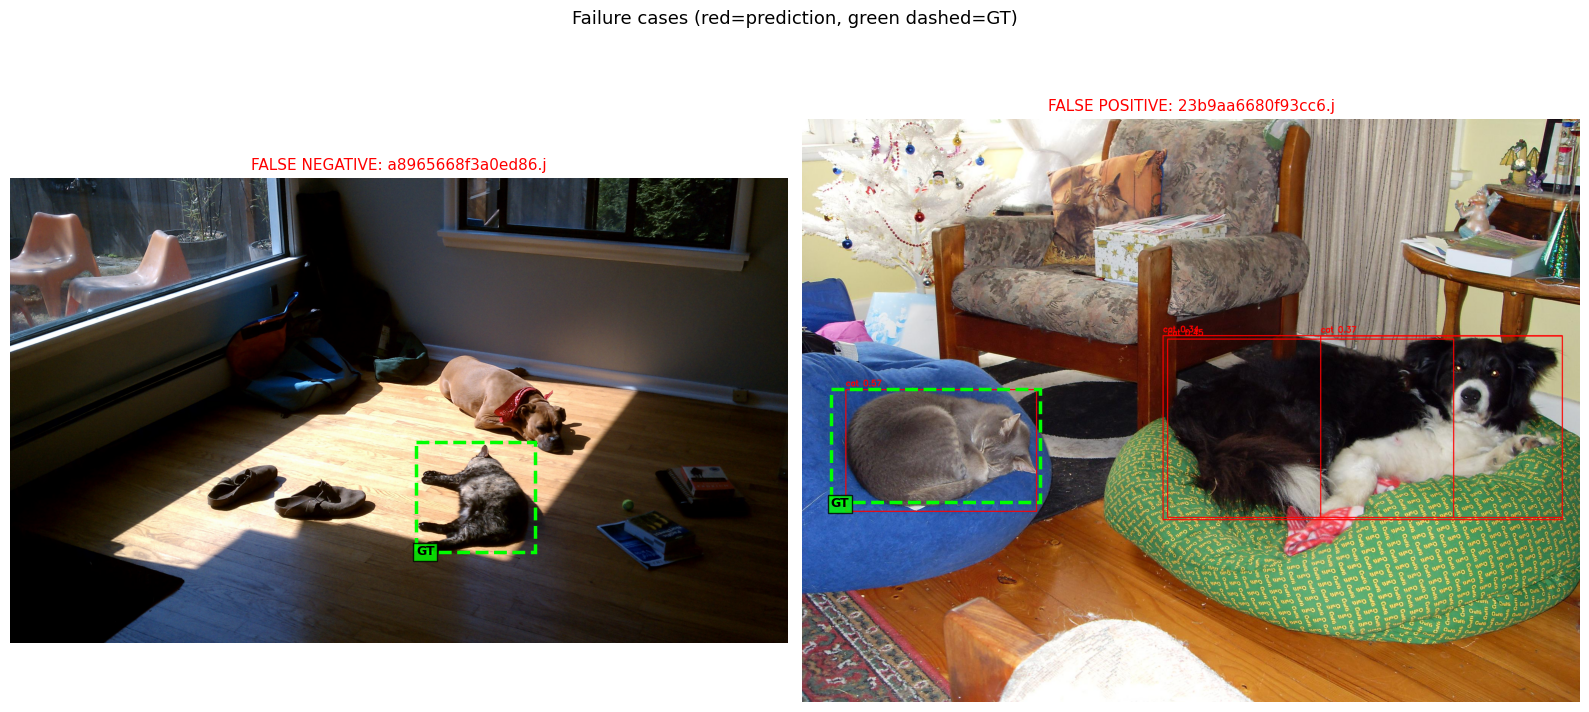

In [12]:
# Scan all test images for failure cases
fn_cases, fp_cases = [], []
for img_path in test_images:
    label_path = Path("/content/clean/labels") / f"{Path(img_path).stem}.txt"
    n_gt = len(label_path.read_text().strip().splitlines()) if label_path.exists() else 0
    r = model.predict(img_path, conf=0.25, verbose=False)[0]
    n_pred = len(r.boxes) if r.boxes is not None else 0
    if n_pred < n_gt:
        fn_cases.append((img_path, n_gt, n_pred))
    elif n_pred > n_gt:
        fp_cases.append((img_path, n_gt, n_pred))

print(f"False negatives: {len(fn_cases)} | False positives: {len(fp_cases)}\n")
print("FN examples:")
for p, gt, pr in fn_cases[:3]: print(f"  {Path(p).name}: GT={gt}, Pred={pr}")
print("FP examples:")
for p, gt, pr in fp_cases[:3]: print(f"  {Path(p).name}: GT={gt}, Pred={pr}")

# Visualize one FN and one FP
fn_img = fn_cases[0][0]
fp_img = fp_cases[0][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, img_path, label in [(axes[0], fn_img, "FALSE NEGATIVE"), (axes[1], fp_img, "FALSE POSITIVE")]:
    img = np.array(Image.open(img_path).convert("RGB"))
    r = model.predict(img_path, conf=0.25, verbose=False)[0]
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0])
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
        cv2.putText(img, f"cat {conf:.2f}", (int(x1), int(y1)-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    ax.imshow(img)
    add_gt_boxes(ax, img_path)
    ax.set_title(f"{label}: {Path(img_path).name[:18]}", color="red", fontsize=11)
    ax.axis("off")

plt.suptitle("Failure cases (red=prediction, green dashed=GT)", fontsize=13)
plt.tight_layout()
plt.show()

Clean images: 3327
Clean labels: 3327
Every image has a matching label: True

Class IDs and object counts:
  class 0: 3895 objects
Total bounding boxes: 3895


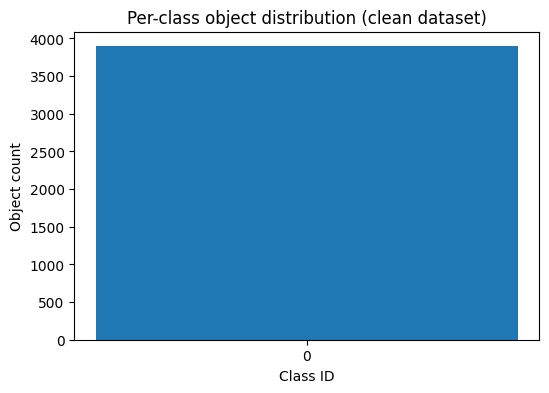


Image size statistics (100 random images):
Width  — min: 720, max: 6000, mean: 2890
Height — min: 665, max: 5616, mean: 2218


In [13]:
from collections import Counter
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

CLEAN_IMAGES = Path("/content/clean/images")
CLEAN_LABELS = Path("/content/clean/labels")

# === 1. Counts ===
n_imgs = len(list(CLEAN_IMAGES.glob("*.jpg")))
n_lbls = len(list(CLEAN_LABELS.glob("*.txt")))
print(f"Clean images: {n_imgs}")
print(f"Clean labels: {n_lbls}")
print(f"Every image has a matching label: {n_imgs == n_lbls}")
print()

# === 2. Class ID distribution ===
class_counts = Counter()
for lbl in CLEAN_LABELS.glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            class_counts[int(parts[0])] += 1

print("Class IDs and object counts:")
for cid, c in sorted(class_counts.items()):
    print(f"  class {cid}: {c} objects")
print(f"Total bounding boxes: {sum(class_counts.values())}")

plt.figure(figsize=(6, 4))
plt.bar([str(c) for c in sorted(class_counts)],
        [class_counts[c] for c in sorted(class_counts)])
plt.xlabel("Class ID")
plt.ylabel("Object count")
plt.title("Per-class object distribution (clean dataset)")
plt.show()

# === 3. Image size statistics (100 random images) ===
random.seed(42)
sample = random.sample(list(CLEAN_IMAGES.glob("*.jpg")), 100)
widths, heights = [], []
for p in sample:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"\nImage size statistics (100 random images):")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")